# Loading the full cleaned dataset

In [421]:
import pandas as pd

df = pd.read_csv('Course Analysis Cleaned Data.csv')
df.head()

,rating_workload,rating_content,rating_teaching,rating_grading,has_midterm,has_final,has_quiz,has_assignment,has_essay,has_project,has_attendance,has_reading,has_presentation,course_name,level,upvote_ratio,insturctor_rating
0,4,5,4,4,False,True,True,False,False,True,True,False,False,COMP1001,1000,NaN,0.0
1,3,3,3,3,True,True,False,False,False,True,False,False,False,COMP1001,1000,NaN,0.0
2,5,5,4,5,False,True,True,False,False,True,True,True,True,COMP1001,1000,NaN,0.0
3,5,5,5,5,False,True,True,False,False,True,True,False,True,COMP1001,1000,NaN,0.0
4,4,5,5,5,False,True,True,True,False,True,True,False,True,COMP1001,1000,NaN,0.0


In [422]:
df.info()
# contains null values in the columns of 'upvote_ratio' and 'instructor_rating'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating_workload    1298 non-null   int64  
 1   rating_content     1298 non-null   int64  
 2   rating_teaching    1298 non-null   int64  
 3   rating_grading     1298 non-null   int64  
 4   has_midterm        1298 non-null   bool   
 5   has_final          1298 non-null   bool   
 6   has_quiz           1298 non-null   bool   
 7   has_assignment     1298 non-null   bool   
 8   has_essay          1298 non-null   bool   
 9   has_project        1298 non-null   bool   
 10  has_attendance     1298 non-null   bool   
 11  has_reading        1298 non-null   bool   
 12  has_presentation   1298 non-null   bool   
 13  course_name        1298 non-null   object 
 14  level              1298 non-null   int64  
 15  upvote_ratio       827 non-null    float64
 16  insturctor_rating  1220 

In [423]:
df.describe()

,rating_workload,rating_content,rating_teaching,rating_grading,level,upvote_ratio,insturctor_rating
count,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,827.000000,1220.000000
mean,3.721109,4.141757,4.155624,4.044684,2466.101695,0.625220,7.008197
std,1.193997,1.056579,1.120553,1.156060,1239.608612,0.404406,4.952930
min,1.000000,1.000000,1.000000,1.000000,1000.000000,0.000000,0.000000
25%,3.000000,4.000000,4.000000,4.000000,1000.000000,0.200000,0.000000
50%,4.000000,4.000000,5.000000,4.000000,2000.000000,0.800000,11.000000
75%,5.000000,5.000000,5.000000,5.000000,3000.000000,1.000000,11.000000
max,5.000000,5.000000,5.000000,5.000000,5000.000000,1.000000,11.000000


# Prepare the Data for Training

In [424]:
from sklearn.model_selection import train_test_split

X = df.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df['rating_workload'] # we will only focus on predicting the workload rating

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1038, 14) (260, 14) (1038,) (260,)


In [425]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

numerical_features = ['upvote_ratio', 'insturctor_rating']
categorical_features = list(X.select_dtypes(include=['bool']).columns)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # choosing median because the mean will be skewed by the few very popular comments with a lot of upvotes, which will have a higher chance of receiving more upvotes as they will be shown at the top
    # ('scaler', StandardScaler()) # some samples will have their 'upvote_ratio' computed to be less than 0
    # ('scaler', MinMaxScaler()) # we don't want to scale 'upvote_ratio' to the range 0-1 or else most of the reviews will get the same 'upvote_ratio' value after imputation
])

cat_pipeline = Pipeline([ 
    # no need for imputation because all columns are complete
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # 'level' = 1000 is NOT being dropped to avoid multicollinearity because it will be used to create new features later on
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, ['level']), # 'level' is the only features that needs to be one-hot encoded; the other features are already binary variables
    ('binary_cat', 'passthrough', categorical_features)
], remainder='drop')

# make sure to fit the preprocessor only on the training data to avoid data leakage
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
df_preprocessed = pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num__upvote_ratio             1038 non-null   float64
 1   num__insturctor_rating        1038 non-null   float64
 2   cat__level_1000               1038 non-null   float64
 3   cat__level_2000               1038 non-null   float64
 4   cat__level_3000               1038 non-null   float64
 5   cat__level_4000               1038 non-null   float64
 6   cat__level_5000               1038 non-null   float64
 7   binary_cat__has_midterm       1038 non-null   float64
 8   binary_cat__has_final         1038 non-null   float64
 9   binary_cat__has_quiz          1038 non-null   float64
 10  binary_cat__has_assignment    1038 non-null   float64
 11  binary_cat__has_essay         1038 non-null   float64
 12  binary_cat__has_project       1038 non-null   float64
 13  bin

In [426]:
df_preprocessed.describe()

,num__upvote_ratio,num__insturctor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation
count,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000
mean,0.696658,7.180154,0.276493,0.263969,0.225434,0.173410,0.060694,0.677264,0.884393,0.183044,0.861272,0.029865,0.351638,0.299615,0.070328,0.106936
std,0.337816,4.913457,0.447479,0.440995,0.418069,0.378784,0.238883,0.467748,0.319907,0.386889,0.345829,0.170297,0.477712,0.458310,0.255821,0.309181
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.818182,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,11.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Feature Engineering (to create new interacting features)

In [427]:
# !pip install seaborn

<Axes: >

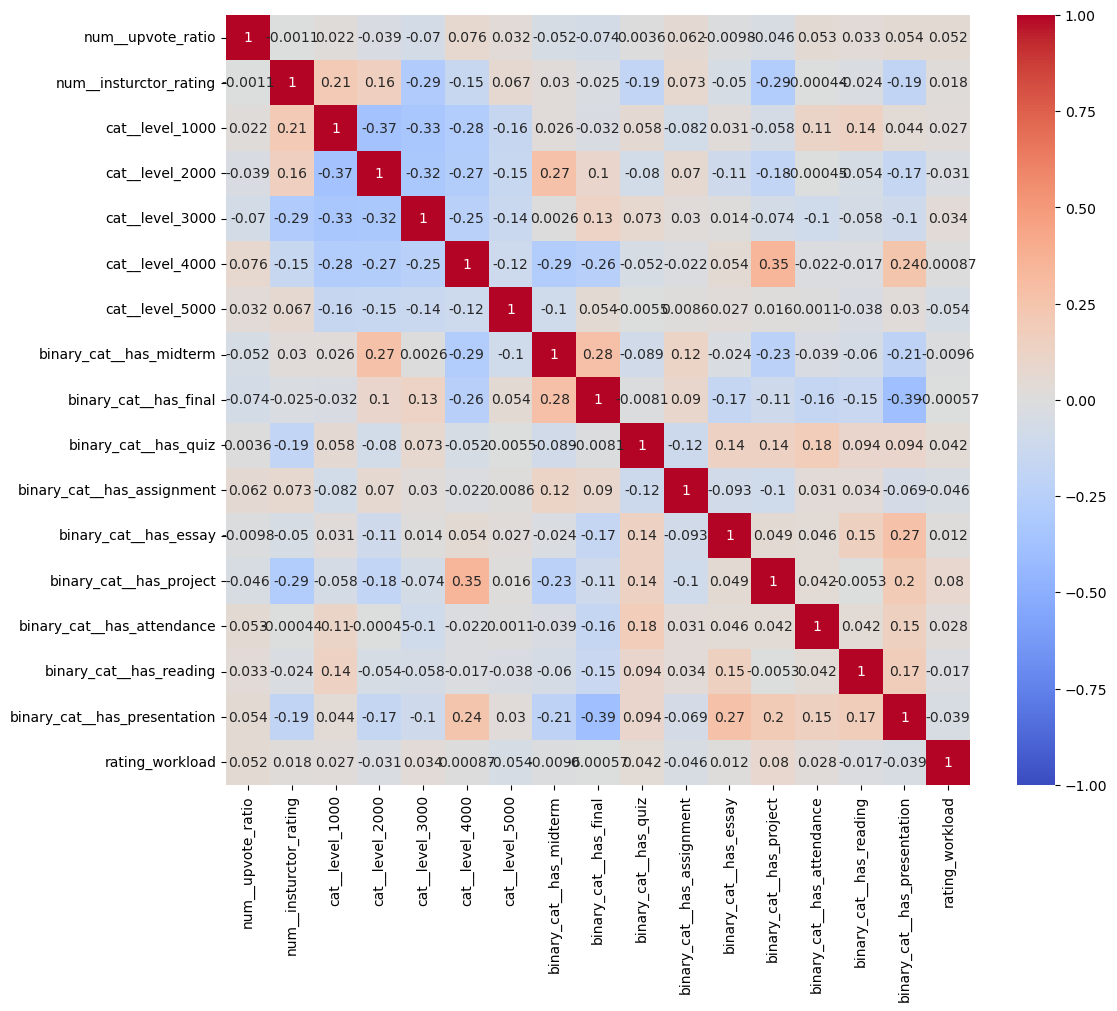

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# no features seem highly correlated with each other

In [429]:
# how much 'testing' does a course have?
df_preprocessed['quiz_and_exams'] = df_preprocessed['binary_cat__has_midterm'] + df_preprocessed['binary_cat__has_final'] + df_preprocessed['binary_cat__has_quiz']

# separating the course levels into two different buckets to capture the bigger picture ('is_higher_level' is represented by 'is_lower_level' being 0)
df_preprocessed['is_lower_level'] = (df_preprocessed['cat__level_1000'].astype('bool') | df_preprocessed['cat__level_2000'].astype('bool')).astype('float64')
# df_preprocessed['is_higher_level'] = (df_preprocessed['cat__level_3000'].astype('bool') | df_preprocessed['cat__level_4000'].astype('bool') | df_preprocessed['cat__level_5000'].astype('bool')).astype('float64')

# how much 'workload' does a course have?
df_preprocessed['sum_workload'] = df_preprocessed['binary_cat__has_assignment'] + df_preprocessed['binary_cat__has_project'] + df_preprocessed['binary_cat__has_essay'] + df_preprocessed['binary_cat__has_presentation'] + df_preprocessed['binary_cat__has_reading']

In [430]:
df_preprocessed.describe()

,num__upvote_ratio,num__insturctor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation,quiz_and_exams,is_lower_level,sum_workload
count,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000
mean,0.696658,7.180154,0.276493,0.263969,0.225434,0.173410,0.060694,0.677264,0.884393,0.183044,0.861272,0.029865,0.351638,0.299615,0.070328,0.106936,1.744701,0.540462,1.420039
std,0.337816,4.913457,0.447479,0.440995,0.418069,0.378784,0.238883,0.467748,0.319907,0.386889,0.345829,0.170297,0.477712,0.458310,0.255821,0.309181,0.721181,0.498600,0.787354
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,0.818182,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000
75%,1.000000,11.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2.000000
max,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,5.000000


<Axes: >

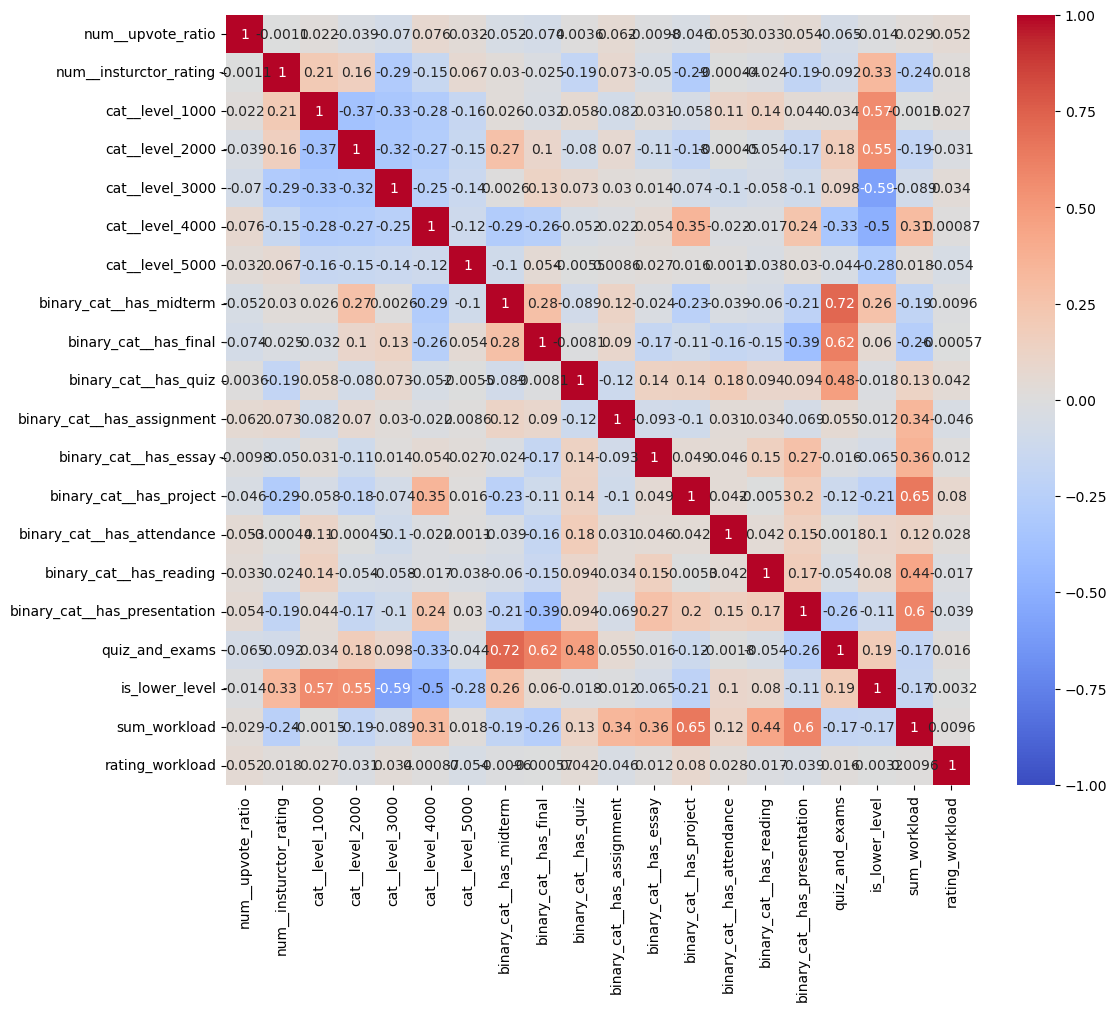

In [431]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [432]:
# removing features that are now moderately (corr coef >= 0.5) correlated with the new engineered features to avoid multicollinearity
df_preprocessed.drop(columns=['cat__level_1000', 'cat__level_2000', 'cat__level_3000', 'cat__level_4000', 'binary_cat__has_midterm', 'binary_cat__has_final', 'binary_cat__has_project', 'binary_cat__has_presentation'], axis=1, inplace=True)

In [433]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
target_corr = correlations['rating_workload'].sort_values(ascending=False).drop('rating_workload')
target_corr

num__upvote_ratio             0.051901
binary_cat__has_quiz          0.042288
binary_cat__has_attendance    0.028132
num__insturctor_rating        0.017552
quiz_and_exams                0.016376
binary_cat__has_essay         0.012356
sum_workload                  0.009605
is_lower_level               -0.003160
binary_cat__has_reading      -0.016987
binary_cat__has_assignment   -0.045740
cat__level_5000              -0.053715
Name: rating_workload, dtype: float64

In [434]:
# dropping 'num__upvote_ratio' as it would be more helpful when used to determine the quality of the reviews for the NLP model
df_engineered = df_preprocessed.drop(['num__upvote_ratio'], axis=1)

# Explorative Analysis

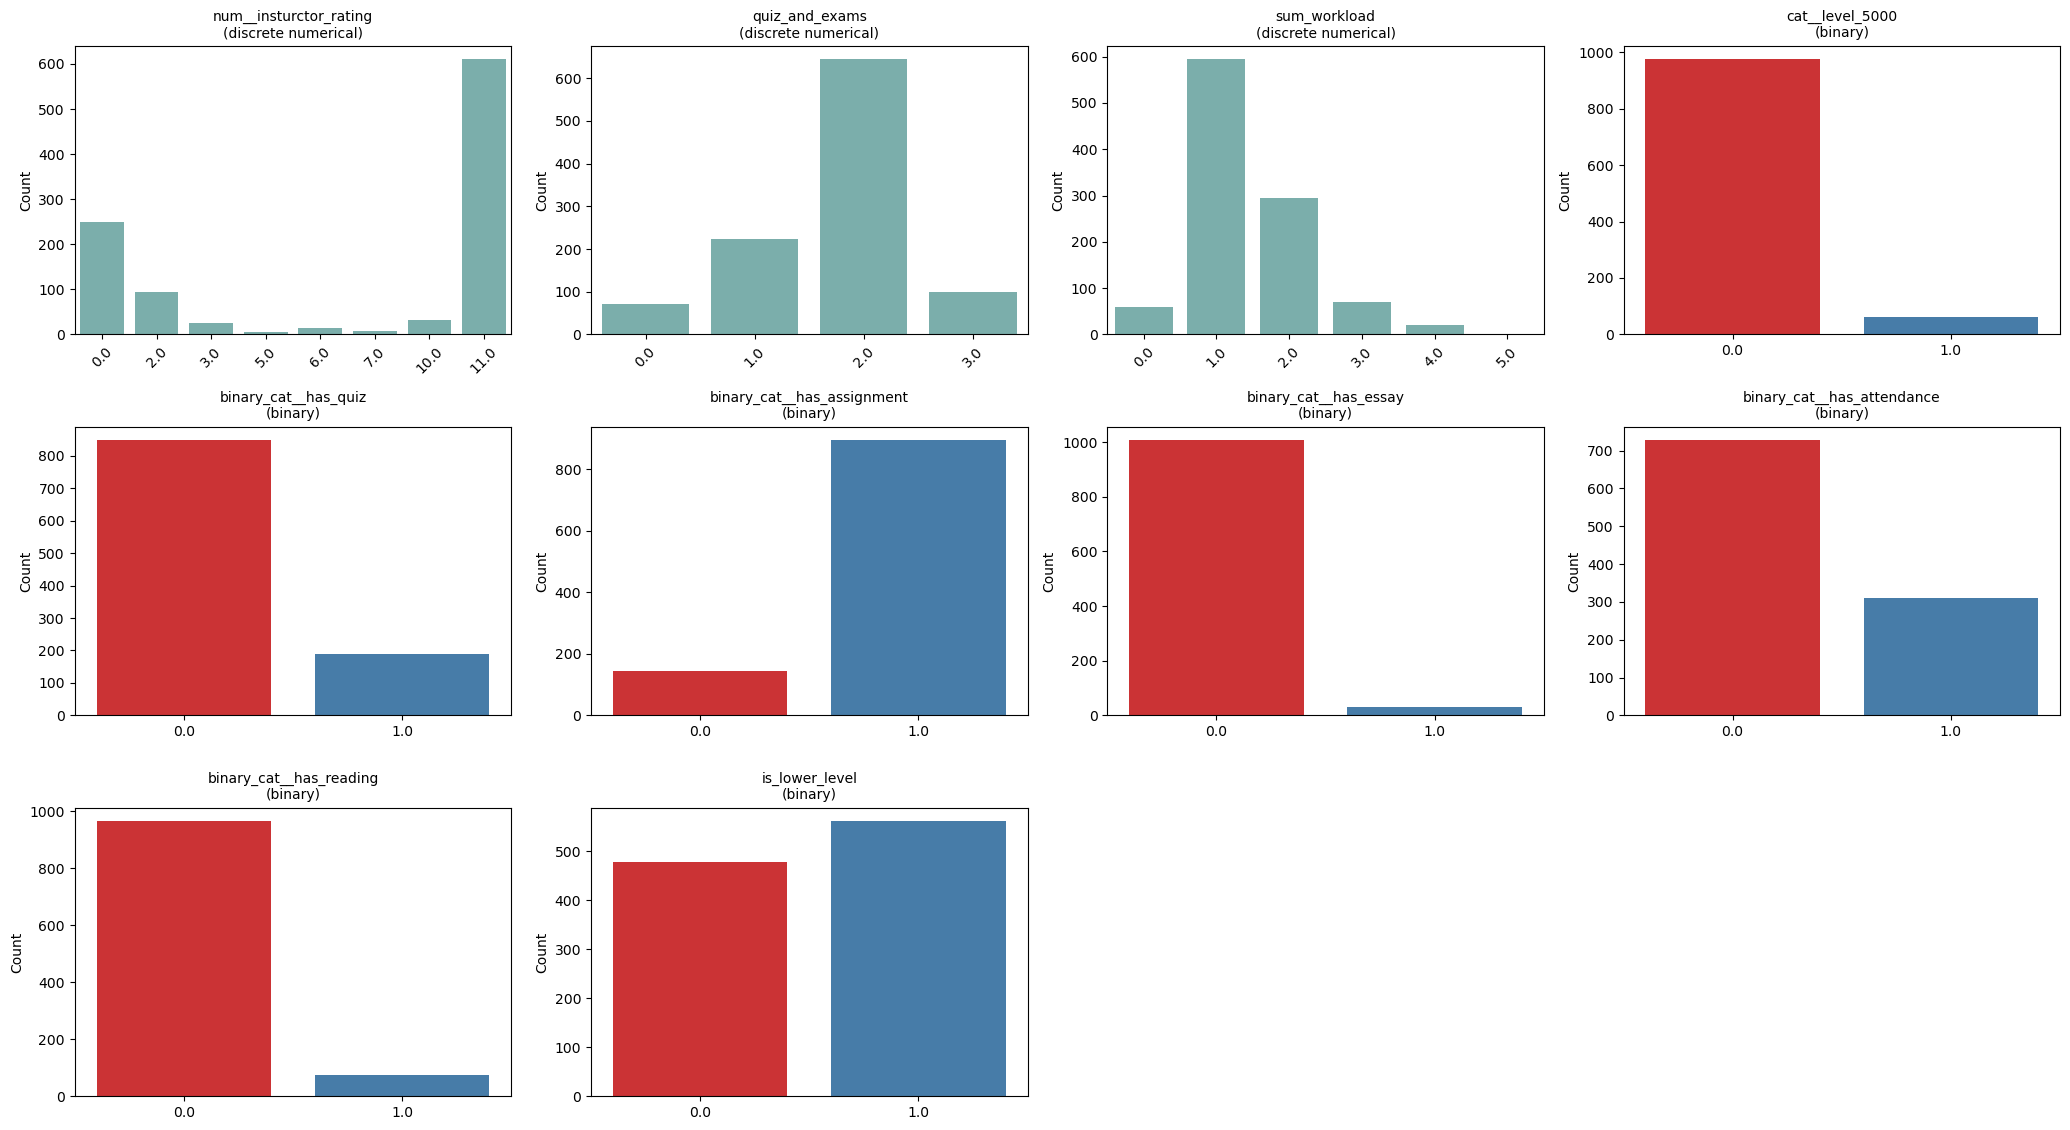

In [435]:
import numpy as np
import math

# Classify features by type
binary_features = [c for c in df_engineered.columns if df_engineered[c].dropna().nunique() <= 2]
categorical_features = [
    c
    for c in df_engineered.columns
    if str(df_engineered[c].dtype) in ["object", "category"] and c not in binary_features
]
numerical_features = [
    c
    for c in df_engineered.columns
    if pd.api.types.is_numeric_dtype(df_engineered[c]) and c not in binary_features
]

# Treat integer-like, low-cardinality numeric features as discrete and use bar plots for them
max_discrete_levels = 10
discrete_numerical_features = []
for c in numerical_features:
    values = df_engineered[c].dropna()
    unique_count = values.nunique()
    is_integer_like = np.all(np.isclose(values, np.round(values)))
    if is_integer_like and unique_count <= max_discrete_levels:
        discrete_numerical_features.append(c)

continuous_numerical_features = [
    c for c in numerical_features if c not in discrete_numerical_features
]

feature_order = continuous_numerical_features + discrete_numerical_features + categorical_features + binary_features
n_features = len(feature_order)

if n_features == 0:
    print("No features found in df_engineered.")
else:
    ncols = 4
    nrows = math.ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_order):
        ax = axes[i]
        series = df_engineered[col]

        if col in continuous_numerical_features:
            sns.histplot(series.dropna(), kde=True, bins=20, ax=ax, color="#4C78A8")
            ax.set_title(f"{col}\n(continuous numerical)", fontsize=10)
            ax.set_ylabel("Count")

        elif col in discrete_numerical_features:
            counts = series.value_counts(dropna=False).sort_index()
            sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#72B7B2")
            ax.set_title(f"{col}\n(discrete numerical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        elif col in categorical_features:
            order = series.value_counts(dropna=False).index
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set2")
            ax.set_title(f"{col}\n(categorical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        else:  # binary feature
            order = sorted(series.dropna().unique())
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set1")
            ax.set_title(f"{col}\n(binary)", fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

    # Hide any unused subplot panels
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [436]:
# Most instructors seem to have either a very high or low rating, resulting in a bimodal distribution. Perhaps binning can be helpful to cleanly distinguish the two peaks.
df_engineered['is_instructor_rating_high'] = (df_engineered['num__insturctor_rating'] > 0.5)
df_engineered.drop('num__insturctor_rating', axis=1, inplace=True)

# It might also be better to exclude the features 'level_5000', 'has_essay', and/or 'has_reading' as they are highly unbalanced and may not provide much useful insights. But this should be done in the hyperparameter tuning section later on.

In [437]:
df_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat__level_5000             1038 non-null   float64
 1   binary_cat__has_quiz        1038 non-null   float64
 2   binary_cat__has_assignment  1038 non-null   float64
 3   binary_cat__has_essay       1038 non-null   float64
 4   binary_cat__has_attendance  1038 non-null   float64
 5   binary_cat__has_reading     1038 non-null   float64
 6   quiz_and_exams              1038 non-null   float64
 7   is_lower_level              1038 non-null   float64
 8   sum_workload                1038 non-null   float64
 9   is_instructor_rating_high   1038 non-null   bool   
dtypes: bool(1), float64(9)
memory usage: 74.1 KB


In [438]:
def build_engineered_features(df_preprocessed_local):
    # Apply the same feature engineering steps.

    df_preprocessed_local['quiz_and_exams'] = (
        df_preprocessed_local['binary_cat__has_midterm']
        + df_preprocessed_local['binary_cat__has_final']
        + df_preprocessed_local['binary_cat__has_quiz']
    )

    df_preprocessed_local['is_lower_level'] = (
        df_preprocessed_local['cat__level_1000'].astype('bool')
        | df_preprocessed_local['cat__level_2000'].astype('bool')
    ).astype('float64')

    df_preprocessed_local['sum_workload'] = (
        df_preprocessed_local['binary_cat__has_assignment']
        + df_preprocessed_local['binary_cat__has_project']
        + df_preprocessed_local['binary_cat__has_essay']
        + df_preprocessed_local['binary_cat__has_presentation']
        + df_preprocessed_local['binary_cat__has_reading']
    )

    df_preprocessed_local.drop(
        columns=[
            'cat__level_1000',
            'cat__level_2000',
            'cat__level_3000',
            'cat__level_4000',
            'binary_cat__has_midterm',
            'binary_cat__has_final',
            'binary_cat__has_project',
            'binary_cat__has_presentation',
        ],
        axis=1,
        inplace=True,
    )

    # df_engineered_local = df_preprocessed_local.drop(['num__upvote_ratio'], axis=1)
    df_preprocessed_local['is_instructor_rating_high'] = (
        df_preprocessed_local['num__insturctor_rating'] > 0.5
    )
    df_engineered_local = df_preprocessed_local.drop('num__insturctor_rating', axis=1)

    return df_engineered_local


df_test_preprocessed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
)
df_test_engineered = build_engineered_features(df_test_preprocessed.copy()).drop(['num__upvote_ratio'], axis=1)

df_test_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat__level_5000             260 non-null    float64
 1   binary_cat__has_quiz        260 non-null    float64
 2   binary_cat__has_assignment  260 non-null    float64
 3   binary_cat__has_essay       260 non-null    float64
 4   binary_cat__has_attendance  260 non-null    float64
 5   binary_cat__has_reading     260 non-null    float64
 6   quiz_and_exams              260 non-null    float64
 7   is_lower_level              260 non-null    float64
 8   sum_workload                260 non-null    float64
 9   is_instructor_rating_high   260 non-null    bool   
dtypes: bool(1), float64(9)
memory usage: 18.7 KB


# Model the Data

In [439]:
# converting the engineered dataframes back to numpy arrays for model training
X_train = df_engineered.to_numpy()
X_test = df_test_engineered.to_numpy()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1038, 10), (260, 10), (1038,), (260,))

In [440]:
# starting with a logistic regression model with ovo (resulting in a total of 10 classifiers, a reasonable number of models to train) for multiclass classification
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
ovo_lr.fit(X_train, y_train)

print(f"OVO LogisticRegression Accuracy: {ovo_lr.score(X_test, y_test)}")

OVO LogisticRegression Accuracy: 0.36538461538461536


In [441]:
# trying a decision tree classifier as well to see if it can outperform logistic regression
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"DecisionTreeClassifier Accuracy: {dt.score(X_test, y_test)}")

DecisionTreeClassifier Accuracy: 0.3576923076923077


In [442]:
# trying a random forest classifier to see if it can do any better
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print(f"RandomForestClassifier Accuracy: {rf.score(X_test, y_test)}")

RandomForestClassifier Accuracy: 0.36153846153846153


### The accuracy with using mostly binary features and a few quantitative engineered featuers isn't high enough. This is likely due to having exams, assignments, projects, presentations, etc. does not imply a courses's workload will be high (for example, the exams might be open-book, assignments in normal courses usually take a lot less effort to complete than those in honors courses.)

# Adding in NLP

In [443]:
df = pd.read_csv('all_courses_cleaned_with_review.csv')
df[['comment_content', 'comment_teaching', 'comment_workload', 'comment_grading']].head()

,comment_content,comment_teaching,comment_workload,comment_grading
0,The course is relatively easy and feels very s...,"Not that important, as mentioned lecture conte...","Weekly Labs Assignment: straightforward, can b...",Grade Weighting:<br />Lab Exam: 40%<br />Proje...
1,"The course is very beginner friendly, and disc...","Unlike other classes, the lectures aren&#039;t...","Workload is manageable, just scope the final p...",Grading is fair: multiple choice quizzes about...
2,Content covers a few basic useful software lik...,ok ge,"not much workload, a bit busy near the project...","Not sure about the grading, but since most stu..."
3,中學ICT野，讀過嘅基本上唔使睇lecture notes<br />冇讀都唔緊要，只係肯花...,"冇睇過佢啲lec video, 聽人講佢教書係麻麻嘅，但係呢科嘅內容應該唔需要睇video,...","每星期有一份5題嘅lecture quiz mc, 可以睇住notes做，只要夠小心就一定滿...","好好grade, 就算唔認真讀，只係肯花時間整proj都一定有b range<br />應該..."
4,Content covers a few useful software like all ...,I think the teaching style is unique and quite...,Workload may be slightly heavy to create a goo...,"Overall, I think it&#039;s great. As long as y..."


In [444]:
df[['comment_content', 'comment_teaching', 'comment_workload', 'comment_grading']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment_content   1290 non-null   object
 1   comment_teaching  1293 non-null   object
 2   comment_workload  1292 non-null   object
 3   comment_grading   1290 non-null   object
dtypes: object(4)
memory usage: 40.7+ KB


# Data Preparation with NLP

In [445]:
import re

def is_english(text):
    has_cjk = bool(re.search(r"[\u4e00-\u9fff]", text)) # reject reviews containing CJK characters (since they have diffrent decodings)
    if has_cjk:
        return False
    return True

df_review = df.dropna(subset=['comment_workload'])
df_review = df_review[df_review['comment_workload'].apply(is_english)] # filter for English-only reviews to avoid tokenizing Chinese characters (as they will be interpreted as a single word in the vocabulary)

print(f"Reviews before filtering: {len(df)}")
print(f"Reviews after filtering: {len(df_review)}")
print("Percent reviews filtered out:", (len(df) - len(df_review)) / len(df) * 100, "%")

Reviews before filtering: 1298
Reviews after filtering: 1170
Percent reviews filtered out: 9.861325115562405 %


In [446]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1170 entries, 0 to 1297
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating_workload    1170 non-null   int64  
 1   rating_content     1170 non-null   int64  
 2   rating_teaching    1170 non-null   int64  
 3   rating_grading     1170 non-null   int64  
 4   has_midterm        1170 non-null   bool   
 5   has_final          1170 non-null   bool   
 6   has_quiz           1170 non-null   bool   
 7   has_assignment     1170 non-null   bool   
 8   has_essay          1170 non-null   bool   
 9   has_project        1170 non-null   bool   
 10  has_attendance     1170 non-null   bool   
 11  has_reading        1170 non-null   bool   
 12  has_presentation   1170 non-null   bool   
 13  course_name        1170 non-null   object 
 14  level              1170 non-null   int64  
 15  upvote_ratio       724 non-null    float64
 16  insturctor_rating  1104 

In [447]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{2,}\b")

X = vectorizer.fit_transform(df_review['comment_workload'])

total_words = vectorizer.get_feature_names_out()
print(f"Vocabulary size before frequency filtering: {len(total_words)}")



# we keep only words that occur more than a certain number of times and whether to use only unigrams (two hyperparameters that can be tuned)
frequency_threshold = 900
ngram = (1, 1)
vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{2,}\b", max_features=frequency_threshold, ngram_range=ngram)

X = vectorizer.fit_transform(df_review['comment_workload'])

total_words = vectorizer.get_feature_names_out()

print(f"Vocabulary size after frequency filtering: {len(total_words)}")
print("Vocabulary (first 100):", total_words[:100])

Vocabulary size before frequency filtering: 4685
Vocabulary size after frequency filtering: 900
Vocabulary (first 100): ['able' 'acceptable' 'according' 'accuracy' 'achieve' 'activity' 'actual'
 'actually' 'add' 'addition' 'additional' 'additionally' 'adequate'
 'advance' 'advanced' 'afternoon' 'ai' 'aim' 'aiming' 'algebra'
 'algorithm' 'algorithms' 'allowed' 'allows' 'amir' 'amp' 'android'
 'annoying' 'answer' 'answering' 'answers' 'anymore' 'apart' 'app'
 'appear' 'application' 'apply' 'appropriate' 'ask' 'asked' 'asking'
 'asks' 'asm' 'ass' 'assembly' 'assignment' 'assignments' 'attempt'
 'attend' 'attendance' 'attending' 'attention' 'audio' 'available'
 'average' 'avoid' 'background' 'bad' 'based' 'basic' 'basically' 'basics'
 'beginner' 'beginners' 'beginning' 'believe' 'best' 'better' 'big'
 'binary' 'bit' 'bonus' 'book' 'books' 'br' 'bring' 'btw' 'bugs' 'build'
 'busy' 'came' 'canvas' 'careful' 'carefully' 'careless' 'case' 'cases'
 'catch' 'cause' 'certain' 'challenge' 'challen

In [448]:
# using the filtered df_review data frame for train_test_split
X = df_review.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading', 'comment_content', 'comment_teaching', 'comment_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df_review['rating_workload'] # we will only focus on predicting the workload rating

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(936, 15) (234, 15) (936,) (234,)


In [449]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

text_feature = 'comment_workload'
svd_components = 100
text_vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{2,}\b", max_features=frequency_threshold, ngram_range=ngram)

# fit only on the training data to avoid data leakage
X_train_text = text_vectorizer.fit_transform(X_train[text_feature].astype(str))
X_test_text = text_vectorizer.transform(X_test[text_feature].astype(str))

# using TruncatedSVD to reduce the dimensionality of the sparse text features
svd = TruncatedSVD(n_components=svd_components, random_state=42)
X_train_text_svd = svd.fit_transform(X_train_text)
X_test_text_svd = svd.transform(X_test_text)

X_train_preprocessed = hstack([csr_matrix(preprocessor.fit_transform(X_train)), csr_matrix(X_train_text_svd)])
X_test_preprocessed = hstack([csr_matrix(preprocessor.transform(X_test)), csr_matrix(X_test_text_svd)])

feature_names = list(preprocessor.get_feature_names_out()) + [f'text_svd_{i}' for i in range(svd_components)]
df_preprocessed = pd.DataFrame.sparse.from_spmatrix(X_train_preprocessed, columns=feature_names)
df_test_preprocessed = pd.DataFrame.sparse.from_spmatrix(X_test_preprocessed, columns=feature_names)

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Columns: 116 entries, num__upvote_ratio to text_svd_99
dtypes: Sparse[float64, 0](116)
memory usage: 1.1 MB


In [450]:
# applying the same feature engineering steps to the preprocessed nlp dataframes
df_engineered = build_engineered_features(df_preprocessed.copy())
df_test_engineered = build_engineered_features(df_test_preprocessed.copy())

df_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Columns: 111 entries, num__upvote_ratio to is_instructor_rating_high
dtypes: Sparse[bool, False](1), Sparse[float64, 0](110)
memory usage: 1.1 MB


/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_12531/598170332.py:11: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  df_preprocessed_local['cat__level_1000'].astype('bool')
/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_12531/598170332.py:12: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  | df_preprocessed_local['cat__level_2000'].astype('bool')
/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_12531/598170332.py:13: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with

In [464]:
# converting the engineered dataframes back to numpy arrays for model training
X_train = df_engineered.to_numpy()
X_test = df_test_engineered.to_numpy()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((936, 111), (234, 111), (936,), (234,))

# Model the Data (with NLP features)

In [452]:
# starting with a logistic regression model with ovo (resulting in a total of 10 classifiers, a reasonable number of models to train) for multiclass classification
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
ovo_lr.fit(X_train, y_train)

print(f"OVO LogisticRegression Accuracy: {ovo_lr.score(X_test, y_test)}")

OVO LogisticRegression Accuracy: 0.405982905982906


In [453]:
# trying a decision tree classifier as well to see if it can outperform logistic regression
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"DecisionTreeClassifier Accuracy: {dt.score(X_test, y_test)}")

DecisionTreeClassifier Accuracy: 0.2777777777777778


In [454]:
# trying a random forest classifier to see if it can do any better
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print(f"RandomForestClassifier Accuracy: {rf.score(X_test, y_test)}")

RandomForestClassifier Accuracy: 0.37606837606837606


### We see an improvement of ~14-17% for the OVO LogisticRegression and RandomForestClassifier model, whereas the DecisionTreeClassifier model was probably overfitting. Now we're making progress as this is about 105-110% better than random guessing (an accuracy of ~20%).

# Optimization (Model Selection & Hyperparameter Tuning)

In [455]:
# !pip install xgboost

In [456]:
# using the filtered df_review data frame for train_test_split
X = df_review.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading', 'comment_content', 'comment_teaching', 'comment_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df_review['rating_workload'] # we will only focus on predicting the workload rating

X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train_tune.shape, X_test_tune.shape, y_train_tune.shape, y_test_tune.shape)

(936, 15) (234, 15) (936,) (234,)


In [457]:
# deciding the max_depth values of rf to try
depths = [tree.tree_.max_depth for tree in rf.estimators_]
print(depths)

[18, 19, 18, 19, 20, 20, 17, 16, 19, 21, 18, 17, 23, 20, 16, 22, 17, 22, 20, 17, 21, 19, 18, 17, 17, 19, 19, 19, 21, 18, 20, 19, 22, 16, 15, 18, 17, 16, 20, 19, 30, 19, 19, 17, 19, 19, 18, 21, 22, 19, 17, 21, 25, 19, 21, 15, 17, 19, 24, 15, 16, 19, 17, 18, 17, 21, 17, 26, 26, 20, 18, 20, 18, 21, 15, 17, 15, 20, 20, 18, 22, 17, 23, 19, 19, 16, 21, 21, 18, 16, 21, 19, 19, 17, 17, 19, 17, 19, 25, 19]


In [458]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
rf = RandomForestClassifier(random_state=42)
ab = AdaBoostClassifier(random_state=42, learning_rate=1.0)
xgb = XGBClassifier(random_state=42)

In [459]:
# help(XGBClassifier)

In [461]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')),
    ('svd', TruncatedSVD(random_state=42)),
])

preprocess_pipe = ColumnTransformer([
    ('tabular', preprocessor, X_train_tune.columns),
    ('text', text_pipe, 'comment_workload'),
], remainder='drop')

# tuning the max_features and ngram_range parameters of the vectorizer as well by constructing pipelines
model_space = {
    'ovo_lr': (
        ovo_lr,
        {
            'preprocess__text__tfidf__max_features': range(700, 1100, 200),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': [100, 200, 400, 600],
            # 'clf__estimator__solver': ['liblinear'], # using liblinear because the default 'lbfgs' solver does not support L1 regularization
            # 'clf__estimator__penalty': ['l1', 'l2'],
            'clf__estimator__C': [0.01, 0.1, 1.0],
        },
    ),
    'rf': (
        rf,
        {
            'preprocess__text__tfidf__max_features': range(700, 1300, 200),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': [100, 200, 400],
            'clf__n_estimators': [200, 400, 800],
            'clf__max_depth': [5, 10, None],
            'clf__min_samples_split': [4, 6, 8],
        },
    ),
    'ab': (
        ab,
        {
            'preprocess__text__tfidf__max_features': range(500, 1100, 200),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': [50, 100, 200, 400],
            'clf__n_estimators': [10, 25, 50, 100],
            # 'clf__learning_rate': [0.01, 0.1, 1.0],
        },
    ),
    'xgb': (
        xgb,
        {
            'preprocess__text__tfidf__max_features': range(300, 1100, 200),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': [50, 100, 200, 300],
            'clf__max_depth': [3, 6, 9],
            'clf__n_estimators': [50, 100, 200, 400],
        },
    ),
}

best_models = {}
search_results = []

for model_name, (estimator, param_grid) in model_space.items():
    full_pipe = Pipeline([
        ('preprocess', preprocess_pipe),
        ('feature_engineering', FunctionTransformer(lambda X: build_engineered_features(pd.DataFrame(X, columns=(list(preprocessor.get_feature_names_out()) + [f'text_svd_{i}' for i in range(X.shape[1] - len(preprocessor.get_feature_names_out()))]))).to_numpy(), validate=False)),
        ('clf', estimator),
    ])

    search = GridSearchCV(
        estimator=full_pipe,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
    )

    if model_name == 'xgb':
        y_train_fit = y_train_tune - y_train_tune.min()
        y_test_eval = y_test_tune - y_test_tune.min()
    else:
        y_train_fit = y_train_tune
        y_test_eval = y_test_tune

    search.fit(X_train_tune, y_train_fit)
    best_models[model_name] = search.best_estimator_

    test_score = search.best_estimator_.score(X_test_tune, y_test_eval)
    search_results.append({
        'model': model_name,
        'best_model': search.best_estimator_,
        'best_params': search.best_params_,
        'cv_best_score': search.best_score_,
        'test_score': test_score,
    })

# 17m 51.4s

/Users/lirenzhang/anaconda3/envs/tensorflow/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


# Final Comparisons & Evaluations

In [462]:
results_df = pd.DataFrame(search_results).sort_values('test_score', ascending=False)
print(results_df['best_params'].tolist())
results_df

[{'clf__n_estimators': 25, 'preprocess__text__svd__n_components': 50, 'preprocess__text__tfidf__max_features': 900, 'preprocess__text__tfidf__ngram_range': (1, 1)}, {'clf__estimator__C': 1.0, 'preprocess__text__svd__n_components': 600, 'preprocess__text__tfidf__max_features': 700, 'preprocess__text__tfidf__ngram_range': (1, 2)}, {'clf__max_depth': 6, 'clf__n_estimators': 100, 'preprocess__text__svd__n_components': 100, 'preprocess__text__tfidf__max_features': 500, 'preprocess__text__tfidf__ngram_range': (1, 2)}, {'clf__max_depth': None, 'clf__min_samples_split': 4, 'clf__n_estimators': 400, 'preprocess__text__svd__n_components': 200, 'preprocess__text__tfidf__max_features': 900, 'preprocess__text__tfidf__ngram_range': (1, 1)}]


,model,best_model,best_params,cv_best_score,test_score
2,ab,"(ColumnTransformer(transformers=[('tabular',\n...","{'clf__n_estimators': 25, 'preprocess__text__s...",0.385635,0.410256
0,ovo_lr,"(ColumnTransformer(transformers=[('tabular',\n...","{'clf__estimator__C': 1.0, 'preprocess__text__...",0.402782,0.380342
3,xgb,"(ColumnTransformer(transformers=[('tabular',\n...","{'clf__max_depth': 6, 'clf__n_estimators': 100...",0.409182,0.367521
1,rf,"(ColumnTransformer(transformers=[('tabular',\n...","{'clf__max_depth': None, 'clf__min_samples_spl...",0.416686,0.354701


In [466]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[(item['model'], item['best_model']) for item in search_results])
voting.fit(X_train_tune, y_train)

print(f"VotingClassifier Accuracy: {voting.score(X_test_tune, y_test)}")

VotingClassifier Accuracy: 0.41025641025641024


### Conclusion: AdaBoostClassifier and VotingClassifier performed best overall, with a test accuracy of ~41.0%